In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

SENTIMENT_COLORS = {
    "Positif": "#2ecc71",
    "Netral":  "#3498db",
    "Negatif": "#e74c3c",
}
ORDER = ["Positif", "Netral", "Negatif"]

## **Pelajari dataset**

In [27]:
df = pd.read_csv("Youtube Sentiment_Roberta.csv")

# Parse waktu → ubah ke WIB (UTC+7)
df["Time"] = pd.to_datetime(df["Time"], utc=True).dt.tz_convert("Asia/Jakarta")
df["Hour"] = df["Time"].dt.hour
df["DayOfWeek"] = df["Time"].dt.day_name()


print("Shape dataset :", df.shape)
print("Kolom         :", df.columns.tolist())
df.head()

Shape dataset : (7199, 10)
Kolom         : ['Channel_Sumber', 'Author', 'Comment_Final', 'Likes', 'Time', 'Tipe_Komentar', 'Sentiment_Rule', 'Sentiment_Roberta', 'Hour', 'DayOfWeek']


,Channel_Sumber,Author,Comment_Final,Likes,Time,Tipe_Komentar,Sentiment_Rule,Sentiment_Roberta,Hour,DayOfWeek
0,Jagat Review,@CheverrlynAdyba,link beli chamon pro 5g,0,2026-03-21 20:04:52+07:00,Utama,Netral,Netral,20,Saturday
1,Jagat Review,@caesarrizkie9742,ngomongin rog kah kamera turun lihat review ca...,0,2026-03-18 03:41:02+07:00,Utama,Positif,Positif,3,Wednesday
2,Jagat Review,@adealfian664,user samsung one ui ui enak ui ui if you can t...,0,2026-03-14 06:27:54+07:00,Utama,Netral,Positif,6,Saturday
3,Jagat Review,@RsyatLyioz,tecno pova ultra 5g,0,2026-03-13 03:11:30+07:00,Utama,Netral,Negatif,3,Friday
4,Jagat Review,@CitraUtut,tolong buatin rekomendasi lebaran,2,2026-03-03 06:12:23+07:00,Utama,Positif,Netral,6,Tuesday


In [28]:
# info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7199 entries, 0 to 7198
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype                       
---  ------             --------------  -----                       
 0   Channel_Sumber     7199 non-null   object                      
 1   Author             7199 non-null   object                      
 2   Comment_Final      7199 non-null   object                      
 3   Likes              7199 non-null   int64                       
 4   Time               7199 non-null   datetime64[ns, Asia/Jakarta]
 5   Tipe_Komentar      7199 non-null   object                      
 6   Sentiment_Rule     7199 non-null   object                      
 7   Sentiment_Roberta  7199 non-null   object                      
 8   Hour               7199 non-null   int32                       
 9   DayOfWeek          7199 non-null   object                      
dtypes: datetime64[ns, Asia/Jakarta](1), int32(1), int64(1), obje

In [29]:
# cek missing value
df.isnull().sum()

,0
Channel_Sumber,0
Author,0
Comment_Final,0
Likes,0
Time,0
Tipe_Komentar,0
Sentiment_Rule,0
Sentiment_Roberta,0
Hour,0
DayOfWeek,0


## **Deteksi Brand HP dari Isi Komentar**

In [30]:
brand_keywords = {
    'Samsung':  ['samsung', 'galaxy', 's24', 's23', 's22', 'a26', 'a36', 'a55', 'm34', 'one ui'],
    'Xiaomi':   ['xiaomi', 'redmi', 'poco', 'hyper os', 'miui'],
    'Infinix':  ['infinix', 'gt30', 'hot50', 'note50'],
    'Tecno':    ['tecno', 'camon', 'pova', 'spark'],
    'Realme':   ['realme'],
    'Vivo':     ['vivo'],
    'Oppo':     ['oppo', 'reno', 'find x'],
    'iPhone':   ['iphone', 'apple', 'ios'],
    'Asus':     ['asus', 'rog', 'zenfone'],
    'Motorola': ['motorola', 'moto g'],
    'iQOO':     ['iqoo'],
}

def detect_brand(comment):
    comment = str(comment).lower()
    for brand, keywords in brand_keywords.items():
        for kw in keywords:
            if kw in comment:
                return brand
    return 'Lainnya'

df['Brand'] = df['Comment_Final'].apply(detect_brand)

print(df['Brand'].value_counts())

Brand
Lainnya     3827
Xiaomi       976
Infinix      487
Samsung      460
Motorola     336
Tecno        316
Oppo         213
Vivo         182
Realme       137
iPhone       127
iQOO          89
Asus          49
Name: count, dtype: int64


In [32]:
df[['Comment_Final', 'Brand', 'Sentiment_Roberta']].head(10)

,Comment_Final,Brand,Sentiment_Roberta
0,link beli chamon pro 5g,Lainnya,Netral
1,ngomongin rog kah kamera turun lihat review ca...,Asus,Positif
2,user samsung one ui ui enak ui ui if you can t...,Samsung,Positif
3,tecno pova ultra 5g,Tecno,Negatif
4,tolong buatin rekomendasi lebaran,Lainnya,Netral
5,infinix gt30 pro harga juta tau harga asli jut...,Infinix,Netral
6,beli toko,Lainnya,Netral
7,samsung s24fe5g aman kah beli,Samsung,Netral
8,bingung seri juta bagus bagus beli handphone l...,Infinix,Negatif
9,camera camon game gt,Tecno,Netral


## **Distribusi Label Sentiment**

In [35]:
print(df["Sentiment_Roberta"].value_counts())
print()
pct = df["Sentiment_Roberta"].value_counts(normalize=True).mul(100).round(1)
print("Persentase:")
print(pct)

Sentiment_Roberta
Netral     4214
Negatif    1663
Positif    1322
Name: count, dtype: int64

Persentase:
Sentiment_Roberta
Netral     58.5
Negatif    23.1
Positif    18.4
Name: proportion, dtype: float64


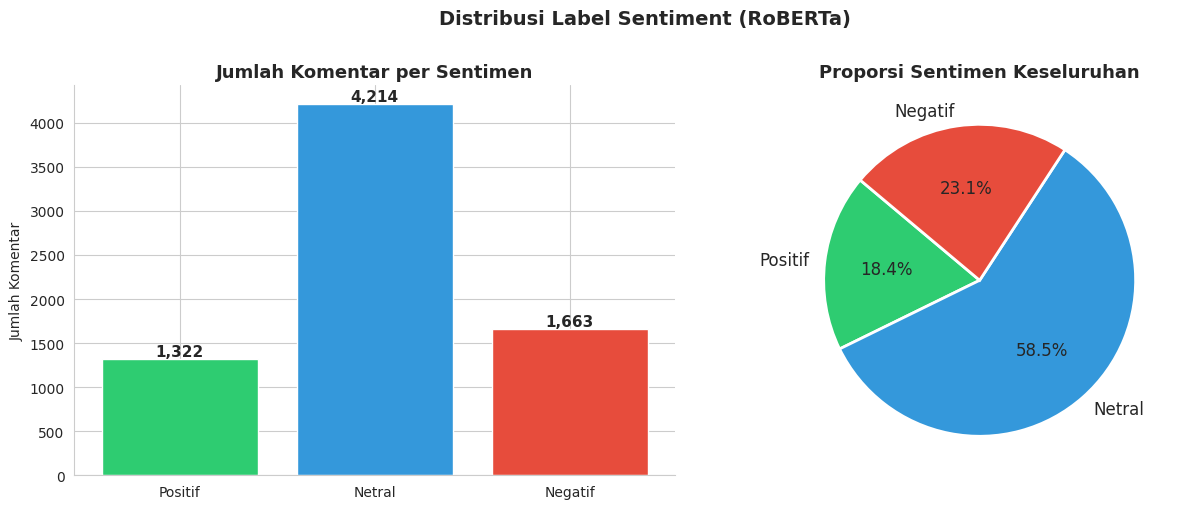

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- bar chart count ---
counts = df["Sentiment_Roberta"].value_counts().reindex(ORDER)
axes[0].bar(ORDER, counts.values, color=[SENTIMENT_COLORS[s] for s in ORDER], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Jumlah Komentar per Sentimen", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Jumlah Komentar")
axes[0].set_xlabel("")

# --- pie chart persentase ---
pct_vals = df["Sentiment_Roberta"].value_counts().reindex(ORDER)
axes[1].pie(
    pct_vals,
    labels=ORDER,
    colors=[SENTIMENT_COLORS[s] for s in ORDER],
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Proporsi Sentimen Keseluruhan", fontsize=13, fontweight="bold")

plt.suptitle("Distribusi Label Sentiment (RoBERTa)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## **Jumlah Komentar per Brand HP**

In [40]:
brand_count = df["Brand"].value_counts()
print(brand_count)
print()
print("Brand HP dengan komentar SEDIKIT (< 200):")
print(brand_count[(brand_count < 200) & (brand_count.index != 'Lainnya')])

Brand
Lainnya     3827
Xiaomi       976
Infinix      487
Samsung      460
Motorola     336
Tecno        316
Oppo         213
Vivo         182
Realme       137
iPhone       127
iQOO          89
Asus          49
Name: count, dtype: int64

Brand HP dengan komentar SEDIKIT (< 200):
Brand
Vivo      182
Realme    137
iPhone    127
iQOO       89
Asus       49
Name: count, dtype: int64


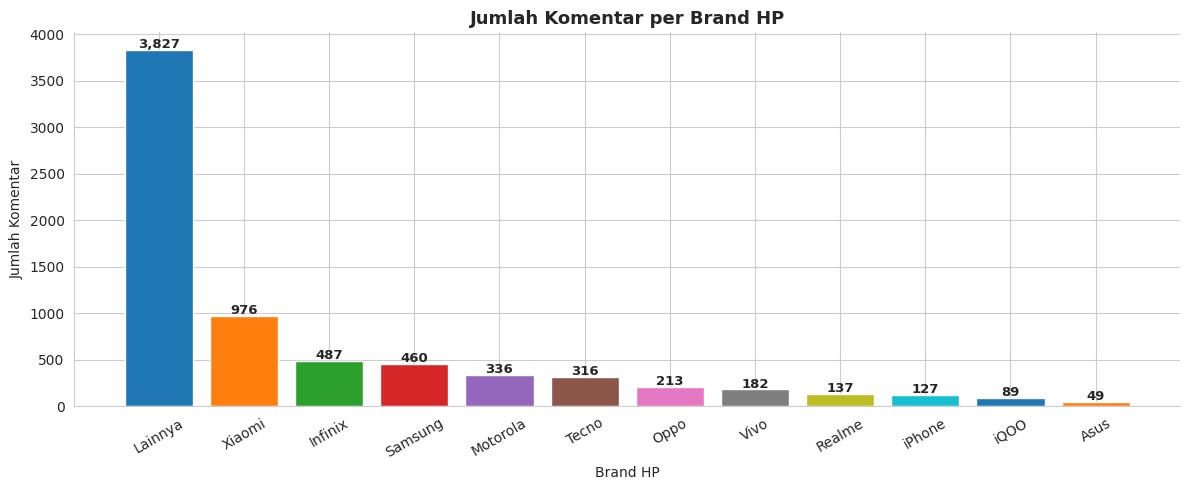

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette("tab10", n_colors=len(brand_count))
bars = ax.bar(brand_count.index, brand_count.values, color=colors, edgecolor="white")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{int(bar.get_height()):,}", ha="center", fontsize=9.5, fontweight="bold")

ax.set_title("Jumlah Komentar per Brand HP", fontsize=13, fontweight="bold")
ax.set_xlabel("Brand HP")
ax.set_ylabel("Jumlah Komentar")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## **Distribusi Sentiment per Brand HP**

In [43]:
# Exclude 'Lainnya' agar analisis fokus pada brand nyata
df_brand = df[df['Brand'] != 'Lainnya'].copy()

brand_sentiment = (
    df_brand.groupby(["Brand", "Sentiment_Roberta"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ORDER, fill_value=0)
)

brand_pct = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0).mul(100).round(1)

print("Jumlah")
print(brand_sentiment)
print()
print("Persentase (%)")
print(brand_pct)

Jumlah
Sentiment_Roberta  Positif  Netral  Negatif
Brand                                      
Asus                    10      24       15
Infinix                 99     323       65
Motorola                52     232       52
Oppo                    38     122       53
Realme                  25      66       46
Samsung                 83     314       63
Tecno                   63     150      103
Vivo                    49     113       20
Xiaomi                 215     632      129
iPhone                  33      69       25
iQOO                    18      45       26

Persentase (%)
Sentiment_Roberta  Positif  Netral  Negatif
Brand                                      
Asus                  20.4    49.0     30.6
Infinix               20.3    66.3     13.3
Motorola              15.5    69.0     15.5
Oppo                  17.8    57.3     24.9
Realme                18.2    48.2     33.6
Samsung               18.0    68.3     13.7
Tecno                 19.9    47.5     32.6
Vivo     

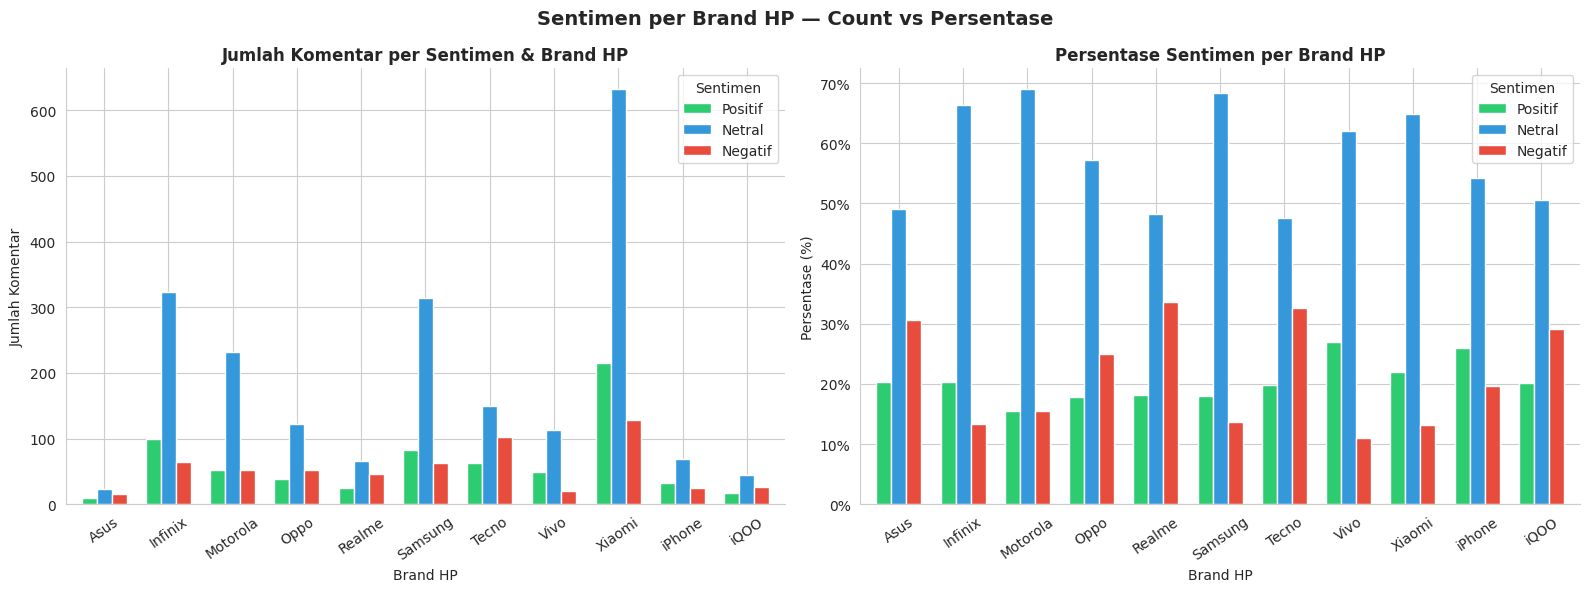

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

brand_sentiment.plot(
    kind="bar", color=[SENTIMENT_COLORS[s] for s in ORDER],
    ax=axes[0], edgecolor="white", width=0.7,
)
axes[0].set_title("Jumlah Komentar per Sentimen & Brand HP", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Brand HP")
axes[0].set_ylabel("Jumlah Komentar")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Sentimen")

brand_pct.plot(
    kind="bar", color=[SENTIMENT_COLORS[s] for s in ORDER],
    ax=axes[1], edgecolor="white", width=0.7,
)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title("Persentase Sentimen per Brand HP", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Brand HP")
axes[1].set_ylabel("Persentase (%)")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="Sentimen")

plt.suptitle("Sentimen per Brand HP — Count vs Persentase", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **Brand HP Paling Positif & Paling Negatif**

In [45]:
most_positive = brand_pct["Positif"].idxmax()
most_negative = brand_pct["Negatif"].idxmax()

print(f"Brand HP PALING POSITIF : {most_positive}  ({brand_pct.loc[most_positive, 'Positif']}% komentar Positif)")
print(f"Brand HP PALING NEGATIF : {most_negative}  ({brand_pct.loc[most_negative, 'Negatif']}% komentar Negatif)")
print()
print("Detail persentase semua brand HP:")
print(brand_pct.sort_values("Positif", ascending=False).to_string())

Brand HP PALING POSITIF : Vivo  (26.9% komentar Positif)
Brand HP PALING NEGATIF : Realme  (33.6% komentar Negatif)

Detail persentase semua brand HP:
Sentiment_Roberta  Positif  Netral  Negatif
Brand                                      
Vivo                  26.9    62.1     11.0
iPhone                26.0    54.3     19.7
Xiaomi                22.0    64.8     13.2
Asus                  20.4    49.0     30.6
Infinix               20.3    66.3     13.3
iQOO                  20.2    50.6     29.2
Tecno                 19.9    47.5     32.6
Realme                18.2    48.2     33.6
Samsung               18.0    68.3     13.7
Oppo                  17.8    57.3     24.9
Motorola              15.5    69.0     15.5


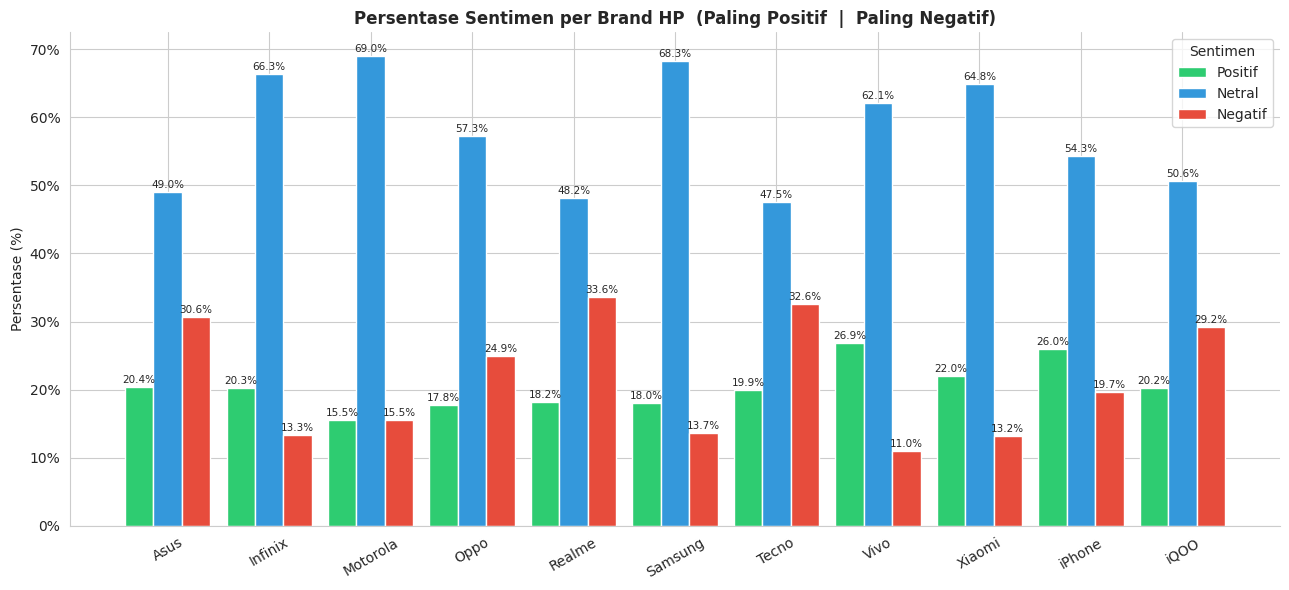

In [46]:
fig, ax = plt.subplots(figsize=(13, 6))

brands = brand_pct.index.tolist()
x = range(len(brands))
width = 0.28

bars_pos = ax.bar([i - width for i in x], brand_pct["Positif"], width,
                  label="Positif", color=SENTIMENT_COLORS["Positif"], edgecolor="white")
bars_net = ax.bar(x,                    brand_pct["Netral"],   width,
                  label="Netral",  color=SENTIMENT_COLORS["Netral"],  edgecolor="white")
bars_neg = ax.bar([i + width for i in x], brand_pct["Negatif"], width,
                  label="Negatif", color=SENTIMENT_COLORS["Negatif"], edgecolor="white")

for bar_group in [bars_pos, bars_net, bars_neg]:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=7.5)

xtick_labels = []
for brand in brands:
    if brand == most_positive:
        xtick_labels.append(f"{brand}")
    elif brand == most_negative:
        xtick_labels.append(f"{brand}")
    else:
        xtick_labels.append(brand)

ax.set_xticks(list(x))
ax.set_xticklabels(xtick_labels, rotation=30, fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Persentase Sentimen per Brand HP  (Paling Positif  |  Paling Negatif)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Persentase (%)")
ax.legend(title="Sentimen")
plt.tight_layout()
plt.show()

## **Analisis Waktu**

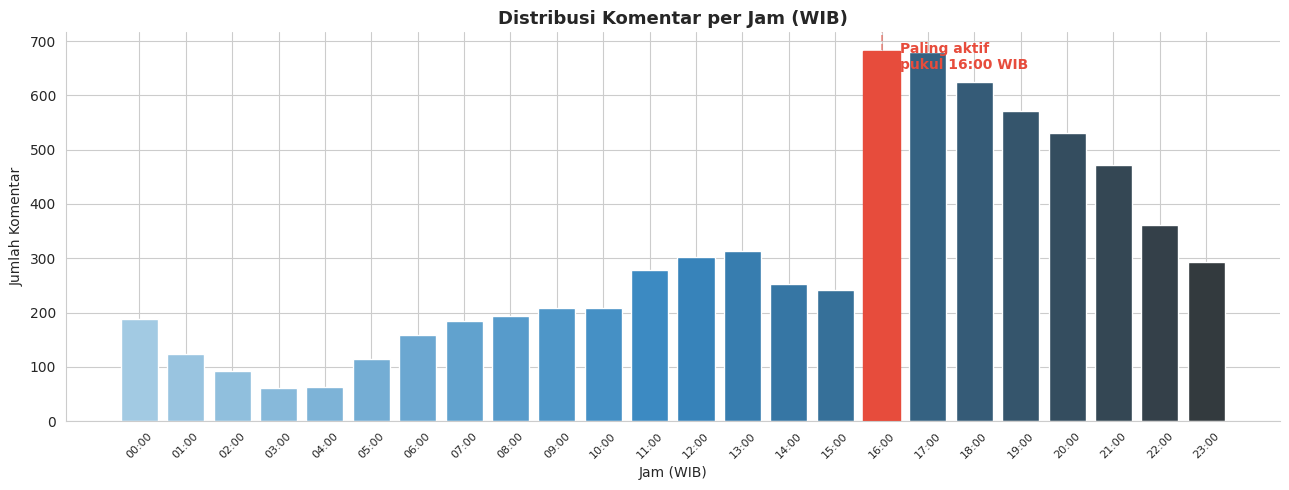

Jam paling aktif : 16:00 WIB  (682 komentar)
Jam paling sepi  : 03:00 WIB  (61 komentar)


In [47]:
hourly = df["Hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [sns.color_palette("Blues_d", 24)[i] for i in range(24)]
bars = ax.bar(hourly.index, hourly.values, color=bar_colors, edgecolor="white")

peak_hour = hourly.idxmax()
bars[peak_hour].set_color("#e74c3c")
ax.axvline(peak_hour, color="#e74c3c", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(peak_hour + 0.4, hourly.max() * 0.95,
        f"Paling aktif\npukul {peak_hour:02d}:00 WIB",
        color="#e74c3c", fontsize=10, fontweight="bold")

ax.set_title("Distribusi Komentar per Jam (WIB)", fontsize=13, fontweight="bold")
ax.set_xlabel("Jam (WIB)")
ax.set_ylabel("Jumlah Komentar")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Jam paling aktif : {peak_hour:02d}:00 WIB  ({hourly.max():,} komentar)")
print(f"Jam paling sepi  : {hourly.idxmin():02d}:00 WIB  ({hourly.min():,} komentar)")

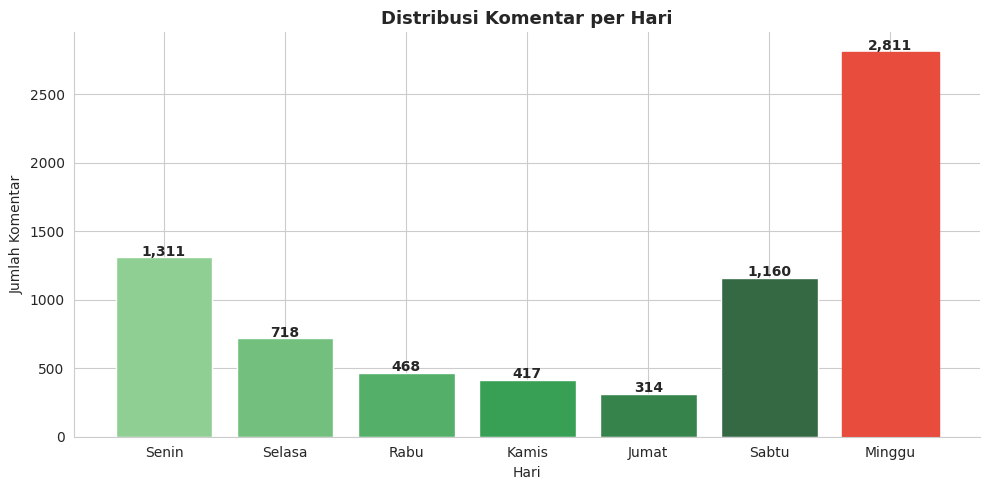

Hari paling aktif : Minggu  (2,811 komentar)
Hari paling sepi  : Jumat  (314 komentar)


In [48]:
DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
DAY_ID    = ["Senin","Selasa","Rabu","Kamis","Jumat","Sabtu","Minggu"]

daily = df["DayOfWeek"].value_counts().reindex(DAY_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(DAY_ID, daily.values,
              color=sns.color_palette("Greens_d", 7), edgecolor="white")

peak_day_idx = daily.values.argmax()
bars[peak_day_idx].set_color("#e74c3c")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{int(bar.get_height()):,}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Distribusi Komentar per Hari", fontsize=13, fontweight="bold")
ax.set_xlabel("Hari")
ax.set_ylabel("Jumlah Komentar")
plt.tight_layout()
plt.show()

print(f"Hari paling aktif : {DAY_ID[peak_day_idx]}  ({daily.values.max():,} komentar)")
print(f"Hari paling sepi  : {DAY_ID[daily.values.argmin()]}  ({daily.values.min():,} komentar)")

## **Sentimen Berdasarkan Jam**

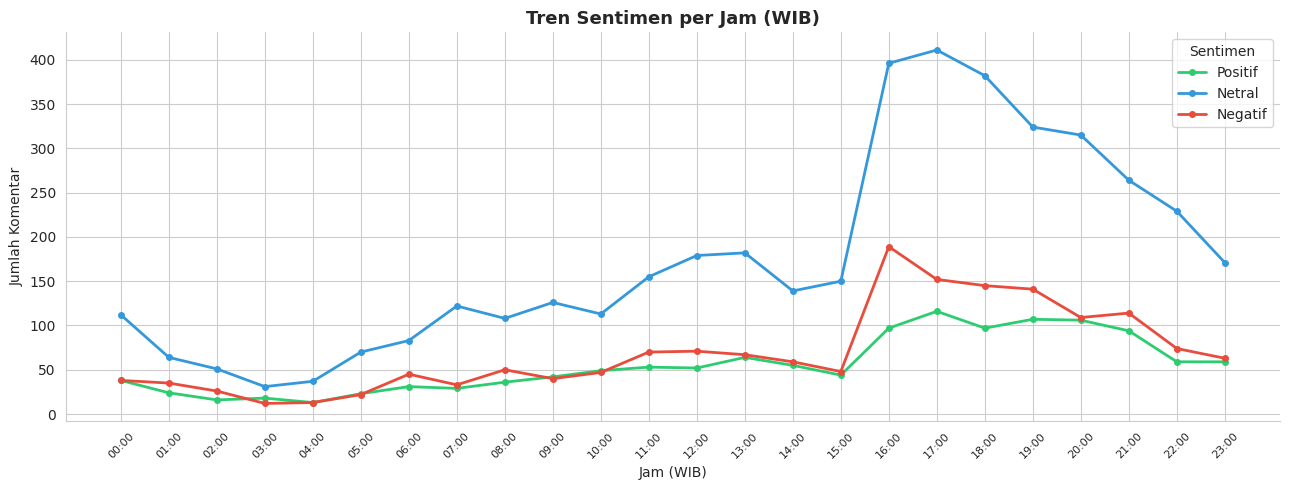

In [50]:
hourly_sent = (
    df.groupby(["Hour", "Sentiment_Roberta"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
for sent in ORDER:
    ax.plot(hourly_sent.index, hourly_sent[sent],
            marker="o", markersize=4, linewidth=2,
            color=SENTIMENT_COLORS[sent], label=sent)

ax.set_title("Tren Sentimen per Jam (WIB)", fontsize=13, fontweight="bold")
ax.set_xlabel("Jam (WIB)")
ax.set_ylabel("Jumlah Komentar")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=8)
ax.legend(title="Sentimen")
plt.tight_layout()
plt.show()

## **Bar chart jumlah komentar per brand**

In [51]:
brand_count = df['Brand'].value_counts()

print(brand_count)

Brand
Lainnya     3827
Xiaomi       976
Infinix      487
Samsung      460
Motorola     336
Tecno        316
Oppo         213
Vivo         182
Realme       137
iPhone       127
iQOO          89
Asus          49
Name: count, dtype: int64


## **Identifikasi brand yang komentarnya sedikit**

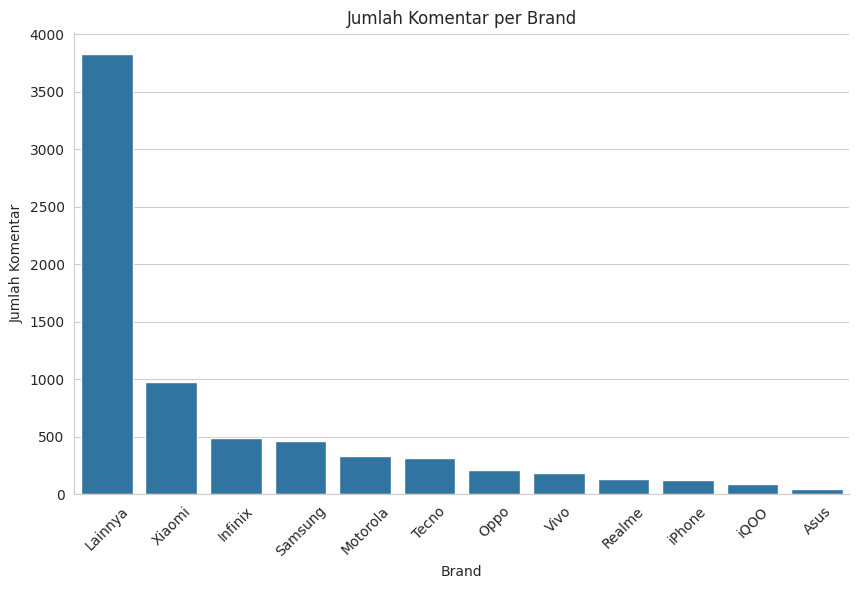

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=brand_count.index,
    y=brand_count.values
)

plt.xticks(rotation=45)

plt.title('Jumlah Komentar per Brand')
plt.xlabel('Brand')
plt.ylabel('Jumlah Komentar')

plt.show()

In [53]:
brand_count.sort_values()

,count
Brand,
Asus,49
iQOO,89
iPhone,127
Realme,137
Vivo,182
Oppo,213
Tecno,316
Motorola,336
Samsung,460


In [54]:
brand_count.sort_values().head(5)

,count
Brand,
Asus,49
iQOO,89
iPhone,127
Realme,137
Vivo,182


## **Hasil**

In [56]:
df.to_csv("youtube_eda_roberta.csv", index=False)
print("Disimpan sebagai youtube_eda_roberta.csv")
print(f"   Rows: {len(df):,}  |  Cols: {df.shape[1]}")

Disimpan sebagai youtube_eda_roberta.csv
   Rows: 7,199  |  Cols: 11
